Paso 1 - Importacion de librerias

In [21]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 5)

Paso 2 - Obtención de los datos

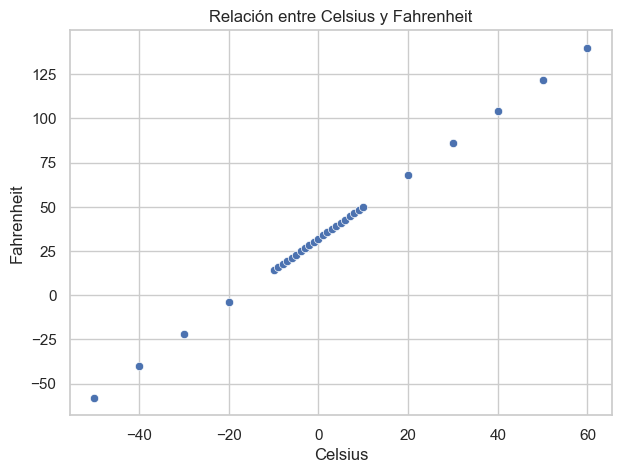

In [24]:

import pandas as pd

# Cargar datos desde el CSV


df_temperatura = pd.read_csv("/Users/Sebastian 1/Desktop/IT Class/Classes/Int_Data_Proc/Act10_HelloW_NeuralNetworks/celsius_a_fahrenheit.csv")




# 2) Mostrar los primeros 5 datos
df_temperatura.head(5)

# 3) Correlación / relación (scatterplot)
sns.scatterplot(x='Celsius', y='Fahrenheit', data=df_temperatura)
plt.title('Relación entre Celsius y Fahrenheit')
plt.show()


Paso 3 - Selección de las variables independiente y objetivo

In [25]:
# Variables independiente (X) y objetivo (y) desde el CSV
x_train = df_temperatura["Celsius"].astype("float32").to_numpy()
y_train = df_temperatura["Fahrenheit"].astype("float32").to_numpy()

Paso 4 - Creación del modelo

In [26]:
print("Creando modelos (capas almacenadas en listas)")

def build_model(layers):
    return tf.keras.Sequential(layers)

# Modelo simple (sin capa oculta)
layers_simple = [
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=1),
]
model_simple = build_model(layers_simple)

# 4) Misma cantidad de capas (misma profundidad), distinto # de neuronas
layers_2capas_10 = [
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=10, activation="relu"),
    tf.keras.layers.Dense(units=1),
]
model_2capas_10 = build_model(layers_2capas_10)

layers_2capas_20 = [
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=20, activation="relu"),
    tf.keras.layers.Dense(units=1),
]
model_2capas_20 = build_model(layers_2capas_20)

# 5) Agregar una o dos capas más
layers_3capas = [
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=20, activation="relu"),
    tf.keras.layers.Dense(units=20, activation="relu"),
    tf.keras.layers.Dense(units=1),
]
model_3capas = build_model(layers_3capas)

layers_4capas = [
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(units=20, activation="relu"),
    tf.keras.layers.Dense(units=20, activation="relu"),
    tf.keras.layers.Dense(units=20, activation="relu"),
    tf.keras.layers.Dense(units=1),
]
model_4capas = build_model(layers_4capas)

Creando modelos (capas almacenadas en listas)


Paso 5 - Compilación del modelo

In [27]:
print("Compilando modelos")

def compile_model(m, lr=0.1):
    m.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="mean_squared_error")

for m in [model_simple, model_2capas_10, model_2capas_20, model_3capas, model_4capas]:
    compile_model(m, lr=0.1)

Compilando modelos


Paso 6 - Entrenamiento del modelo

Entrenando modelos
simple -> loss final: 222.8156
2capas_10 -> loss final: 0.2669
2capas_20 -> loss final: 0.1585
3capas -> loss final: 0.0905
4capas -> loss final: 0.0258


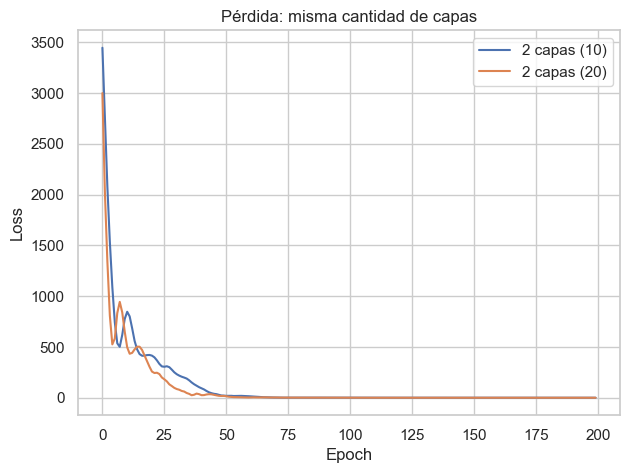

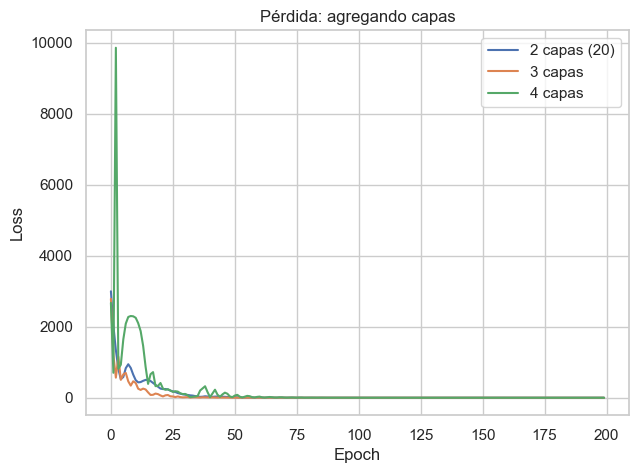

In [28]:
EPOCHS = 200

print("Entrenando modelos")
histories = {}

models = {
    "simple": model_simple,
    "2capas_10": model_2capas_10,
    "2capas_20": model_2capas_20,
    "3capas": model_3capas,
    "4capas": model_4capas,
}

for name, m in models.items():
    h = m.fit(x=x_train, y=y_train, epochs=EPOCHS, verbose=0)
    histories[name] = h
    print(f"{name} -> loss final: {h.history['loss'][-1]:.4f}")

# 4) Comparación: misma cantidad de capas (2 capas densas) -> 10 vs 20 neuronas
plt.plot(histories["2capas_10"].history["loss"], label="2 capas (10)")
plt.plot(histories["2capas_20"].history["loss"], label="2 capas (20)")
plt.title("Pérdida: misma cantidad de capas")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 5) Comparación: agregando una o dos capas más
plt.plot(histories["2capas_20"].history["loss"], label="2 capas (20)")
plt.plot(histories["3capas"].history["loss"], label="3 capas")
plt.plot(histories["4capas"].history["loss"], label="4 capas")
plt.title("Pérdida: agregando capas")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


Análisis

In [30]:
Temp_C = 100.0
Temp_C_array = np.array([[Temp_C]], dtype=np.float32)

# Usamos uno de los modelos entrenados (puedes cambiarlo si deseas)
model_usado = model_3capas
Temp_F_pred = model_usado.predict(Temp_C_array, verbose=0)

print("La temperatura de Predicción es: ", Temp_F_pred)

Temp_F_eq = 9/5 * Temp_C + 32
print("La temperatura de Ecuación es: ", Temp_F_eq)

La temperatura de Predicción es:  [[212.12953]]
La temperatura de Ecuación es:  212.0
